In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_OG = pd.read_csv("zomato.csv", encoding="latin1")
df = df_OG.copy()

In [3]:
#Get an overview of the dataset

df.sample(5)
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [4]:
#Data Cleaning

In [5]:
#Check for missing values

missing = pd.DataFrame({
    "missing count": df.isnull().sum(),
    "missing %": (df.isnull().sum()/len(df))*100
})

missing = missing[missing["missing count"]>0]
print("No empty values found") if missing.empty else missing

,missing count,missing %
rate,7775,15.033741
phone,1208,2.335789
location,21,0.040606
rest_type,227,0.438927
dish_liked,28078,54.291626
cuisines,45,0.087012
approx_cost(for two people),346,0.669026


In [6]:
#Drop non-essential columns, or columns with huge no. of missing values

df.drop(columns=["phone", "dish_liked", "url", "address"], inplace=True) #majority values are missing and phone column is not useful

In [7]:
#Fix the column names & data (Remove trailing spaces/ Give meaningful name to column)

df.columns = df.columns.str.strip() #fixing column names

for col in df.select_dtypes(include="object"):
    df[col] = df[col].str.strip() #fixing column data

df.rename(columns={"rate": "rating"}, inplace=True)

In [8]:
#Check for duplicate rows

duplicates = df.duplicated().sum()

if duplicates > 0:
    duplicate_rows = df[df.duplicated(keep=False)].drop_duplicates()
    display(duplicate_rows)
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    
else:
    print("No duplicates found !")

,name,online_order,book_table,rating,votes,location,rest_type,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
553,My Tea House,Yes,Yes,NEW,0,Banashankari,Casual Dining,"Continental, Asian, North Indian, Tea",500,"[('Rated 4.0', ""RATED\n So apparently I visit...","['MTH Signature Soup', 'Minestrone Veg', 'Broc...",Dine-out,Banashankari
2195,Shiv Sagar,No,No,3.6/5,10,Bannerghatta Road,Food Court,"South Indian, Beverages",400,"[('Rated 4.0', 'RATED\n It was yesterday I vi...",[],Dine-out,Bannerghatta Road
4338,Biryani Treat,No,No,NaN,0,Bellandur,Quick Bites,Biryani,400,[],[],Delivery,Bellandur
7325,Nawab Di Biryani,Yes,No,NEW,0,Whitefield,"Takeaway, Delivery","Biryani, Mughlai",400,"[('Rated 4.0', 'RATED\n Ordered paneer tikka ...","['Paneer Tikka Biryani', 'Veg Lucknowi Biryani...",Delivery,Brookefield
9082,Healthy Parathawala,Yes,No,NEW,0,BTM,Quick Bites,North Indian,200,[],"['Aloo Paratha Chole Combo', 'Gobi Paratha Cho...",Delivery,BTM
...,...,...,...,...,...,...,...,...,...,...,...,...,...
46405,House Of Candy,Yes,No,NaN,0,Malleshwaram,Confectionery,Desserts,200,[],[],Delivery,Rajajinagar
49050,Sri Ganesh Juice Junction,Yes,No,3.5 /5,6,Bellandur,Beverage Shop,"Juices, Fast Food",200,"[('Rated 4.0', 'RATED\n A perfect place to dr...",[],Delivery,Sarjapur Road
49431,Biryani Treat,No,No,NaN,0,Bellandur,Quick Bites,Biryani,400,[],[],Delivery,Sarjapur Road
50366,House Of Candy,Yes,No,NaN,0,Whitefield,Confectionery,Desserts,200,[],[],Delivery,Whitefield


In [9]:
#In zomato's dataset, there are also restaurants with same names & addresses, but different reviews & listed_in(type)

duplicates = df.duplicated(subset=["name", "listed_in(city)"]).sum()

if duplicates>0:
    duplicate_rows = df[df.duplicated(
        subset=["name", "listed_in(city)"], 
        keep=False
    )].drop_duplicates(
        subset=["name", "listed_in(city)"]
    )
    display(duplicate_rows)
    df.reset_index(inplace=True)
    df.drop_duplicates(subset=["name", "listed_in(city)"], inplace=True)
else:
    print("No Duplicates found !")


,name,online_order,book_table,rating,votes,location,rest_type,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...,...,...,...
51378,Basaveshwara Kanawali,No,No,3.5 /5,13,Whitefield,Quick Bites,South Indian,250,"[('Rated 3.0', 'RATED\n An average place at b...",[],Dine-out,Whitefield
51381,New Shalimar Hotel,No,No,NaN,0,Whitefield,Quick Bites,"North Indian, Biryani",250,"[('Rated 5.0', 'RATED\n Unbelievable but the ...",[],Dine-out,Whitefield
51544,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,"ITPL Main Road, Whitefield",Bar,Finger Food,"2,500","[('Rated 4.0', 'RATED\n Nice and friendly pla...",[],Dine-out,Whitefield
51547,The Nest - The Den Bengaluru,No,No,3.4 /5,13,"ITPL Main Road, Whitefield","Bar, Casual Dining","Finger Food, North Indian, Continental","1,500","[('Rated 5.0', 'RATED\n Great ambience , look...",[],Dine-out,Whitefield


In [10]:
#Check for data types

#Change the dtype of "rate" from object to float64
df["rating"] = df["rating"].str.split("/").str[0] #Converts "3.9/5" to "3.9"
df["rating"] = pd.to_numeric(df["rating"], errors="coerce") #float64


#Change the dtype of "cost" from object to float64
df["approx_cost(for two people)"] = df["approx_cost(for two people)"].str.replace(",","",regex=False) #remove ","
df["approx_cost(for two people)"] = pd.to_numeric(df["approx_cost(for two people)"], errors="coerce") #float64

In [11]:
#Filling the missing values

#location: Replace nan with unknown
df["location"] = df["location"].fillna("Unknown")

#rest_type: Replace nan with unknown
df["rest_type"] = df["rest_type"].fillna("Unknown")

#cuisin: Replace nan with unknown
df["cuisines"] = df["cuisines"].fillna("Unknown")

#approx_cost(for two people): Replace nan with median value 
df["approx_cost(for two people)"] = df["approx_cost(for two people)"].fillna(df["approx_cost(for two people)"].median()) 

In [12]:
#Check for unique values, or diversity/range of values in categorical columns

for col in ["rest_type", "listed_in(type)", "listed_in(city)"]:
    print(f"Column: {col}")
    print(f"Unique Values: {df[col].nunique()}")
    print(f"{df[col].value_counts(normalize=True) * 100}") #normalize converts it to fraction & *100 makes it %
    print("*"*125)

Column: rest_type
Unique Values: 92
rest_type
Quick Bites              38.846627
Casual Dining            18.689435
Delivery                  7.714403
Takeaway, Delivery        5.839462
Cafe                      5.053502
                           ...    
Pop Up                    0.006313
Bhojanalya                0.006313
Dessert Parlor, Kiosk     0.003156
Bakery, Food Court        0.003156
Cafe, Food Court          0.003156
Name: proportion, Length: 92, dtype: float64
*****************************************************************************************************************************
Column: listed_in(type)
Unique Values: 7
listed_in(type)
Delivery              75.048136
Dine-out              13.961049
Cafes                  5.369149
Buffet                 2.777690
Desserts               2.720874
Pubs and bars          0.075755
Drinks & nightlife     0.047347
Name: proportion, dtype: float64
************************************************************************************

In [13]:
#Confirm that no values are missing

df.isnull().sum()
#rating values are intentionally kept missing, as it will alter the data

index                             0
name                              0
online_order                      0
book_table                        0
rating                         6961
votes                             0
location                          0
rest_type                         0
cuisines                          0
approx_cost(for two people)       0
reviews_list                      0
menu_item                         0
listed_in(type)                   0
listed_in(city)                   0
dtype: int64

In [14]:
#Get the numeric summary

df.describe()

,index,rating,votes,approx_cost(for two people)
count,31681.000000,24720.000000,31681.000000,31681.000000
mean,25385.725040,3.668584,219.581958,510.942047
std,14854.931135,0.430027,658.540064,420.117887
min,0.000000,1.800000,0.000000,40.000000
25%,12530.000000,3.400000,5.000000,300.000000
50%,25433.000000,3.700000,32.000000,400.000000
75%,38165.000000,4.000000,153.000000,600.000000
max,51651.000000,4.900000,16832.000000,6000.000000


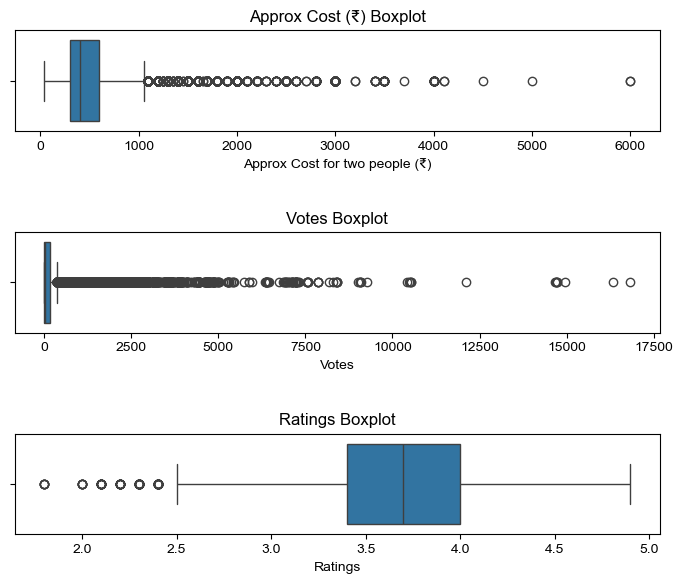

In [15]:
#Tracking outliers

fig, ax = plt.subplots(3,1, figsize=(7,6))

sns.set_theme(style="darkgrid")

sns.boxplot(
    data = df,
    x = "approx_cost(for two people)",
    ax = ax[0]
)
ax[0].set_xlabel("Approx Cost for two people (₹)")
ax[0].set_title("Approx Cost (₹) Boxplot")


sns.boxplot(
    data = df,
    x = "votes",
    ax = ax[1]
)
ax[1].set_xlabel("Votes")
ax[1].set_title("Votes Boxplot")

sns.boxplot(
    data = df,
    x = "rating",
    ax = ax[2]
)
ax[2].set_xlabel("Ratings")
ax[2].set_title("Ratings Boxplot")

fig.tight_layout()
plt.subplots_adjust(hspace=1)
plt.show()

In [16]:
#Exploratory Data Analysis

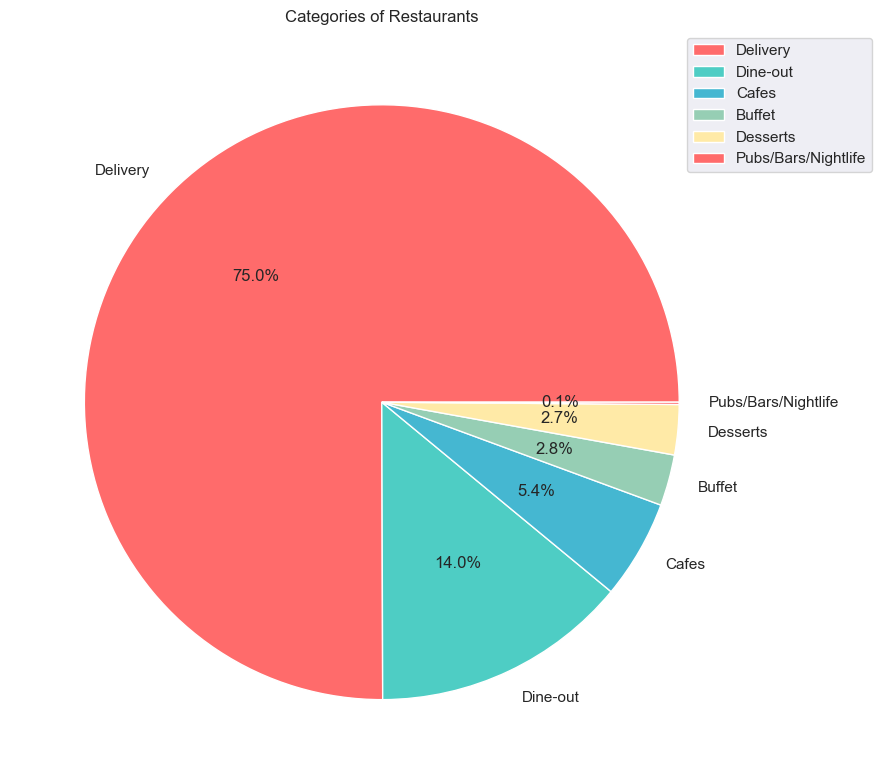

In [17]:
#1. Restaurant categories

rest_cat = df["listed_in(type)"].value_counts().reset_index()
rest_cat.drop([5,6], inplace=True) #Very small portion. So, converting it into a single category
rest_cat.loc[5] = ["Pubs/Bars/Nightlife", 39]

custom_colors = ["#FF6B6B", "#4ECDC4", "#45B7D1", "#96CEB4", "#FFEAA7"]

sns.set_theme(style="dark")

fig, ax = plt.subplots(figsize=(10,8))
ax.pie(
    rest_cat["count"],
    autopct = "%1.1f%%",
    labels = rest_cat["listed_in(type)"],
    colors = custom_colors
    
)

ax.set_title("Categories of Restaurants")

ax.legend(
    bbox_to_anchor=(0.9, 1),
    loc="upper left"
)
fig.tight_layout()
plt.show()

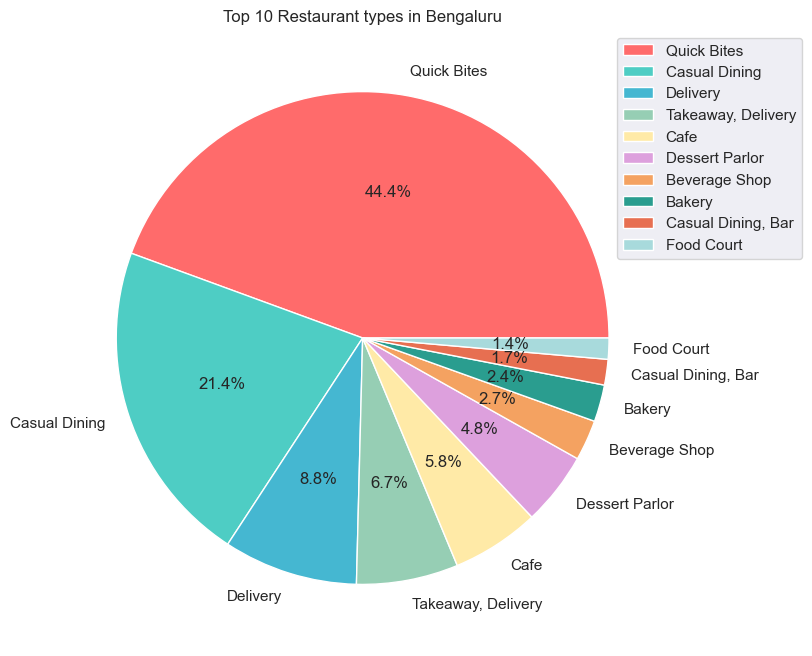

In [18]:
#2. Top 10 Types of Restaurants

rest_types = pd.DataFrame(df["rest_type"].value_counts().reset_index().head(10))

custom_colors = [
    "#FF6B6B",
    "#4ECDC4",
    "#45B7D1",
    "#96CEB4",
    "#FFEAA7",
    "#DDA0DD",
    "#F4A261",
    "#2A9D8F",
    "#E76F51",
    "#A8DADC"
]

fig, ax = plt.subplots(figsize=(10,8))
ax.pie(
    rest_types["count"],
    colors = custom_colors,
    autopct="%1.1f%%",
    labels = rest_types["rest_type"]
)

plt.title("Top 10 Restaurant types in Bengaluru")
plt.legend(
    bbox_to_anchor=(0.9, 1),
    loc="upper left"
)

plt.show()

C:\Users\heer4\AppData\Local\Temp\ipykernel_16136\2526579938.py:25: UserWarning: Glyph 131 (\x83) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\heer4\AppData\Local\Temp\ipykernel_16136\2526579938.py:25: UserWarning: Glyph 130 (\x82) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\heer4\AppData\Local\Temp\ipykernel_16136\2526579938.py:25: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()
C:\Users\heer4\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 131 (\x83) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\heer4\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 130 (\x82) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


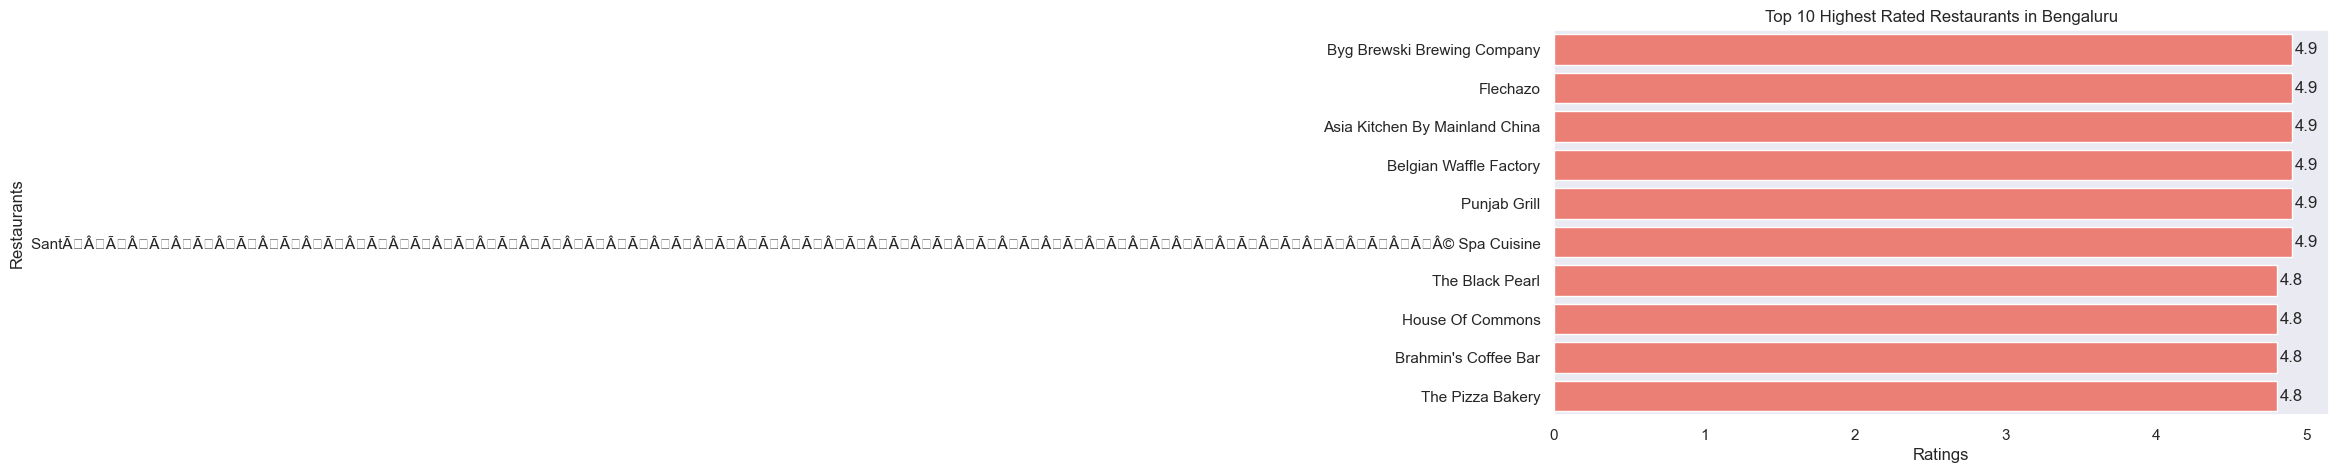

In [19]:
#3. Top 10 rated restaurants 
df.loc[28304, "name"] = "Santé Spa Cuisine" #75 letters big name converted to short
df_unique = df.drop_duplicates(subset=(["name"])).reset_index(drop=True)

top_rated = df_unique[df_unique["votes"]>=100].sort_values(by=["rating", "votes"], ascending=[False, False]).head(10).reset_index()

sns.set_theme(style="dark")

fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(
    data = top_rated,
    x = "rating",
    y = "name",
    color = "#ff6f61",
    ax = ax
)

for i, v in enumerate(top_rated["rating"]): #i: idx, v:rating_vals
    ax.text(v+0.02, i, v, va="center")

ax.set_title("Top 10 Highest Rated Restaurants in Bengaluru")
ax.set_xlabel("Ratings")
ax.set_ylabel("Restaurants")

fig.tight_layout()
plt.show()

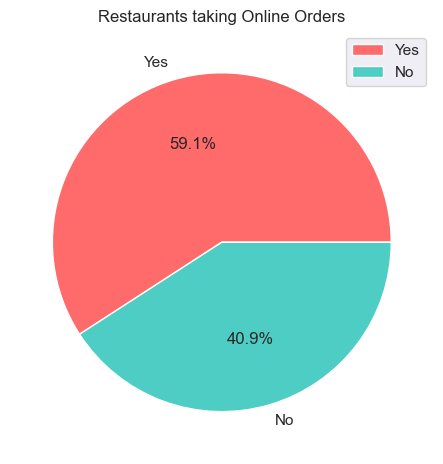

In [20]:
#4. Restaurants taking online orders

rest_dev = df["online_order"].value_counts().reset_index()
custom_colors = ["#FF6B6B", "#4ECDC4"]

sns.set_theme(style="darkgrid")

fig, ax = plt.subplots()
ax.pie(
    rest_dev["count"],
    autopct="%1.1f%%",
    labels = rest_dev["online_order"],
    colors = custom_colors
)

ax.set_title("Restaurants taking Online Orders")

ax.legend()
fig.tight_layout()
plt.show()

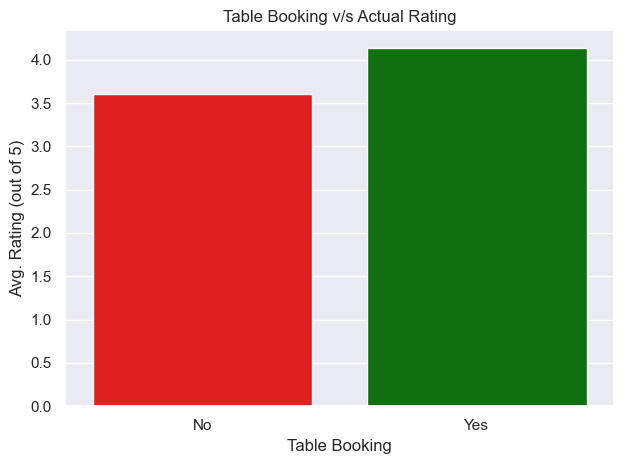

In [21]:
#5. Table booking rate v/s Rating
book_table_rate = df.groupby("book_table")["rating"].mean().reset_index()

sns.set_theme(style="darkgrid")

fig, ax = plt.subplots()
sns.barplot(
    data = book_table_rate,
    x = "book_table",
    y = "rating",
    hue = "book_table",
    palette = {"Yes": "green", "No": "red"},
    ax = ax
)

ax.set_xlabel("Table Booking")
ax.set_ylabel("Avg. Rating (out of 5)")
ax.set_title("Table Booking v/s Actual Rating")

fig.tight_layout()
plt.show()

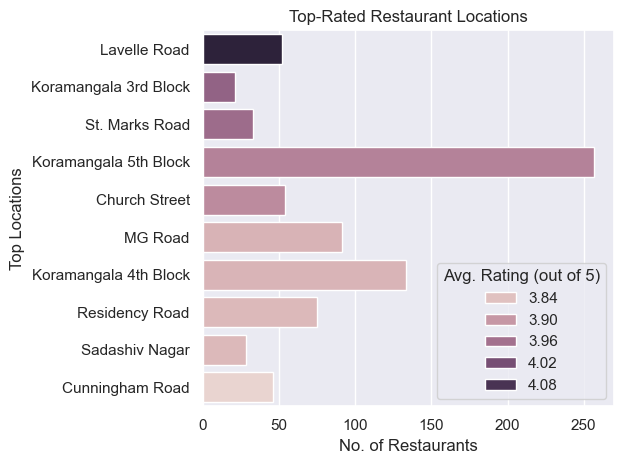

In [22]:
#6. Best locations on the basis of top-rated restaurants

best_locations = df.groupby("location").agg(
    avg_rating = ("rating", "mean"),
    restaurants = ("name", "nunique")
).query("restaurants >= 20").sort_values("avg_rating", ascending=False).reset_index().head(10)

sns.set_theme(style="darkgrid")

fig, ax = plt.subplots()
sns.barplot(
    data = best_locations,
    x = "restaurants",
    y = "location",
    hue = "avg_rating",
    ax = ax
)

ax.legend(title="Avg. Rating (out of 5)")
ax.set_xlabel("No. of Restaurants")
ax.set_ylabel("Top Locations")
ax.set_title("Top-Rated Restaurant Locations")

fig.tight_layout()
plt.show()

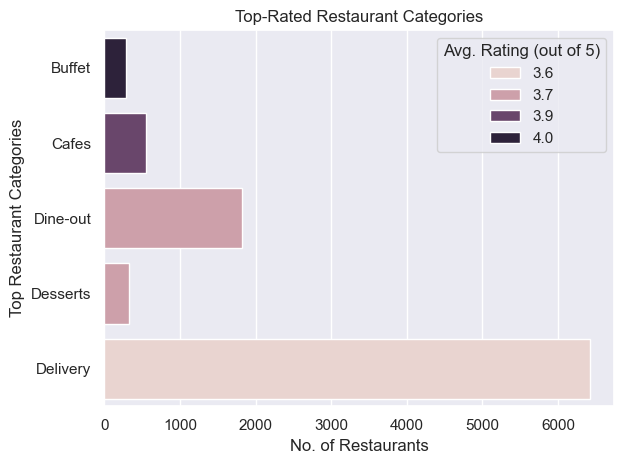

In [23]:
#7. Top-rated Categories of Restaurants

top_rated_cat = df.groupby("listed_in(type)").agg(
    avg_rating = ("rating", "mean"),
    restaurants = ("name", "nunique")
).query("restaurants >= 20").sort_values("avg_rating", ascending=False).reset_index()
top_rated_cat["avg_rating"] = top_rated_cat["avg_rating"].round(1)

sns.set_theme(style="darkgrid")

fig, ax = plt.subplots()
sns.barplot(
    data = top_rated_cat,
    x = "restaurants",
    y = "listed_in(type)",
    hue = "avg_rating",
    ax = ax
)

ax.legend(title="Avg. Rating (out of 5)")
ax.set_xlabel("No. of Restaurants")
ax.set_ylabel("Top Restaurant Categories")
ax.set_title("Top-Rated Restaurant Categories")

fig.tight_layout()
plt.show()

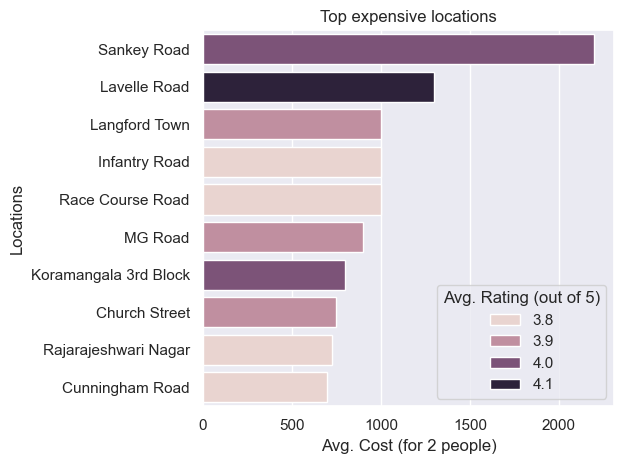

In [24]:
#8. Top locations with expensive restaurants

exp_loc = df.groupby("location").agg(
    avg_cost = ("approx_cost(for two people)", "median"),
    restaurants = ("name", "nunique"),
    avg_rating = ("rating", "mean")
).sort_values("avg_cost", ascending=False).reset_index().head(10)
exp_loc["avg_rating"] = exp_loc["avg_rating"].round(1)

sns.set_theme(style="darkgrid")

fig, ax = plt.subplots()
sns.barplot(
    data = exp_loc,
    x = "avg_cost",
    y = "location",
    hue = "avg_rating",
    ax = ax
)

ax.legend(title="Avg. Rating (out of 5)")
ax.set_xlabel("Avg. Cost (for 2 people)")
ax.set_ylabel("Locations")
ax.set_title("Top expensive locations")

fig.tight_layout()
plt.show()

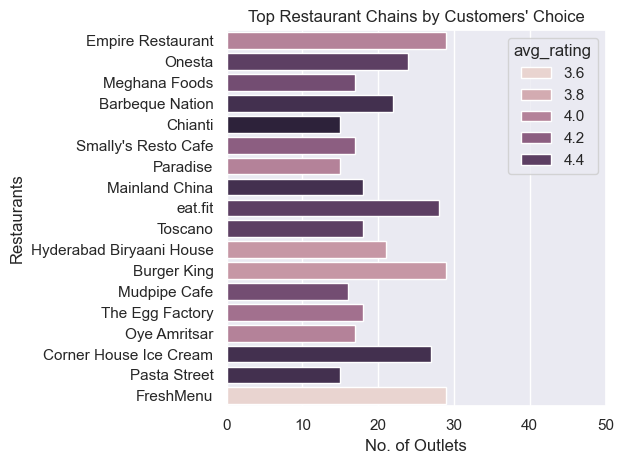

In [25]:
#9. Famous Restaurant chains in Bengaluru

top_chains = df.groupby("name").agg(
    outlets = ("name", "count"),
    avg_rating = ("rating", "mean"),
    total_votes = ("votes", "sum")
).query("outlets >= 15 and total_votes >= 15_000").sort_values(
    ["total_votes", "avg_rating"], ascending=[False, False]
).reset_index()
top_chains["avg_rating"] = top_chains["avg_rating"].round(1)

sns.set_theme(style="darkgrid")

fig, ax = plt.subplots()
sns.barplot(
    data = top_chains,
    x = "outlets",
    y = "name",
    hue = "avg_rating",
    ax = ax
)

ax.set_xlim(0,50)
ax.set_xlabel("No. of Outlets")
ax.set_ylabel("Restaurants")
ax.set_title("Top Restaurant Chains by Customers' Choice")

fig.tight_layout()
plt.show()